# GloFAS reforecast trigger skill by lead time : Somali region, Ethiopia

The operational question for a trigger: at what lead time does the GloFAS forecast
still catch the FloodScan-defined flood events? Uses the 2003-2023 v4 reforecast
(Gu + Deyr months, leads 1-7 days) at the channel-snapped reporting points
(full 11-member ensemble) and the grid stations (control run only : the ensemble
fetch is incomplete there).

Trigger definition tested: at lead L, trigger fires on an issue date if at least
P% of ensemble members exceed the station's SEASONAL RP-T threshold (Kiremt flows
dominate the annual maxima, so Gu / Deyr triggers need their own levels: same
finding as notebook 02). Scored per season against the FloodScan RP3 event
catalogue with the same +/-7 day overlap convention. The reforecast months are
Mar-May + Oct-Dec, so the Gu side has no June issues (events peaking in June can
only be caught by late-May issues at long lead) and thresholds are the v4 fit
(the reforecast archive is v4 only).

Also checks forecast-vs-reanalysis climatology per lead (the Somalia lesson:
GEOGloWS forecasts run 0.6-0.7x their retrospective and RP thresholds never fire;
GloFAS v4 was ratio ~1.0 : verify the same holds here before trusting
reanalysis-fitted thresholds on forecasts).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd

STAGE = "dev"
PROJECT_PREFIX = "ds-aa-eth-flooding"

RP_TEST = [2, 3, 5]           # thresholds worth testing as triggers
PROB_TEST = [0.3, 0.5, 0.7]   # ensemble exceedance probability
FS_RP = 3                     # benchmark events: FloodScan RP3
MATCH_TOLERANCE_DAYS = 7
GLOFAS_MERGE_GAP_DAYS = 7
SCORE_START, SCORE_END = "2003-01-01", "2023-12-31"
ENSEMBLE_STATIONS = ["G1904", "RP_4205_0415", "RP_4045_0535"]
SEASON_MONTHS = {"gu": [3, 4, 5, 6], "kiremt": [7, 8, 9], "deyr": [10, 11, 12]}


def month_season(m: int) -> str:
    for season, months in SEASON_MONTHS.items():
        if m in months:
            return season
    return "jilaal"


## Load inputs

In [2]:
mapping = stratus.load_csv_from_blob(
    f"{PROJECT_PREFIX}/processed/glofas/station_zone_mapping_all.csv", stage=STAGE
).set_index("station_id")
thresholds = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/glofas/glofas_return_periods.parquet", stage=STAGE
)
# reforecast archive is v4, so trigger thresholds must be the v4 fit
thr = thresholds[thresholds["version"] == "v4_0"].set_index(
    ["station_id", "season", "rp"]
)["threshold_gumbel"]
fs_events = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/floodscan/floodscan_event_catalogue.parquet", stage=STAGE
)
fs_events = fs_events[fs_events["fs_rp"] == FS_RP]

grid = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/glofas/glofas_discharge.parquet", stage=STAGE
)
rp_pts = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/glofas/glofas_discharge_reporting_points.parquet", stage=STAGE
)
raw = pd.concat([grid, rp_pts], ignore_index=True)

rf = raw[raw["dataset"] == "reforecast"].copy()
rf["issued_time"] = pd.to_datetime(rf["issued_time"]).dt.normalize()
rf["valid_time"] = pd.to_datetime(rf["valid_time"]).dt.normalize()
# grid stations: keep control only (perturbed fetch incomplete, stops 2012)
rf = rf[
    rf["station_id"].isin(ENSEMBLE_STATIONS)
    | (rf["product_type"] == "control_reforecast")
]
rf["member"] = np.where(
    rf["product_type"] == "control_reforecast", -1, rf.get("number", -1)
)
print(rf.groupby(["station_id", "product_type"])["issued_time"].agg(["min", "max", "nunique"]))

                                                  min        max  nunique
station_id   product_type                                                
G1904        control_reforecast            2003-03-27 2023-11-25     1740
             ensemble_perturbed_reforecast 2003-03-27 2023-11-25     1740
RP_4045_0535 control_reforecast            2003-03-27 2023-11-25     1740
             ensemble_perturbed_reforecast 2003-03-27 2023-11-25     1740
RP_4205_0415 control_reforecast            2003-03-27 2023-11-25     1740
             ensemble_perturbed_reforecast 2003-03-27 2023-11-25     1740
station_1    control_reforecast            2003-03-27 2023-11-25     3500
station_2    control_reforecast            2003-03-27 2023-11-25     3500
station_3    control_reforecast            2003-03-27 2023-11-25     3500
station_4    control_reforecast            2003-03-27 2023-11-25     3500
station_5    control_reforecast            2003-03-27 2023-11-25     3500


## Forecast vs reanalysis climatology

Median forecast discharge per lead over the reforecast issue dates, divided by the
reanalysis median on the same valid dates. Ratio near 1: reanalysis-fitted RP
thresholds transfer to the forecast without refitting.

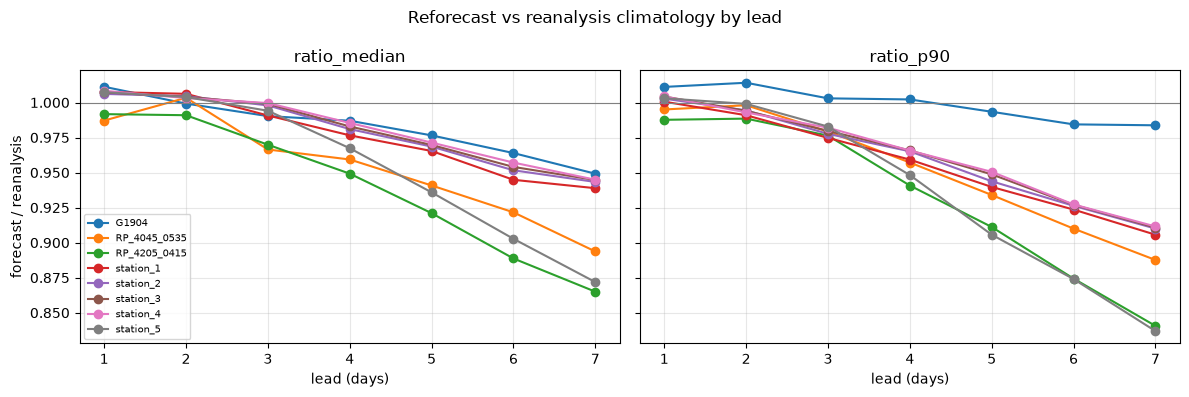

In [3]:
rean = raw[raw["dataset"] == "reanalysis"].copy()
rean["valid_time"] = pd.to_datetime(rean["valid_time"]).dt.normalize()
rean["date"] = rean["valid_time"] - pd.Timedelta(days=1)
rean = (
    rean.sort_values(["valid_time", "product_type"])
    .drop_duplicates(["station_id", "date"], keep="last")
    .set_index(["station_id", "date"])["discharge"]
)

rows = []
for sid in rf["station_id"].unique():
    sub = rf[rf["station_id"] == sid]
    for lead, g in sub.groupby("leadtime_days"):
        valid_dates = g["valid_time"].unique()
        try:
            r = rean.loc[sid].reindex(pd.DatetimeIndex(valid_dates)).dropna()
        except KeyError:
            continue
        if len(r) == 0 or r.median() == 0:
            continue
        rows.append({
            "station_id": sid, "lead": int(lead),
            "ratio_median": g["discharge"].median() / r.median(),
            "ratio_p90": g["discharge"].quantile(0.9) / r.quantile(0.9),
        })
clim = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, col in zip(axes, ["ratio_median", "ratio_p90"]):
    for sid, g in clim.groupby("station_id"):
        ax.plot(g["lead"], g[col], marker="o", label=sid)
    ax.axhline(1.0, color="grey", linewidth=0.8)
    ax.set_xlabel("lead (days)")
    ax.set_title(col)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("forecast / reanalysis")
axes[0].legend(fontsize=7)
plt.suptitle("Reforecast vs reanalysis climatology by lead")
plt.tight_layout()
plt.show()

## Trigger backtest

For ensemble stations: P(members >= RP threshold) per issue | lead. For control-only
stations: deterministic exceedance. Trigger episodes (gaps under 7 days merged on
issue dates) scored against FloodScan events.

In [4]:
def extract_episodes_dates(dates: pd.DatetimeIndex, merge_gap_days: int) -> list:
    if len(dates) == 0:
        return []
    dates = pd.DatetimeIndex(sorted(dates))
    episodes = [[dates[0], dates[0]]]
    for d in dates[1:]:
        if (d - episodes[-1][1]).days <= merge_gap_days:
            episodes[-1][1] = d
        else:
            episodes.append([d, d])
    return episodes


def score_episodes(episodes: list, events: pd.DataFrame) -> dict:
    tol = pd.Timedelta(days=MATCH_TOLERANCE_DAYS)
    hits_ev = sum(
        any((s - tol <= e["end"]) and (t + tol >= e["start"]) for s, t in episodes)
        for _, e in events.iterrows()
    )
    hits_ep = sum(
        ((events["start"] - tol <= t) & (events["end"] + tol >= s)).any()
        for s, t in episodes
    ) if len(events) else 0
    return {
        "n_events": len(events), "n_triggers": len(episodes),
        "pod": hits_ev / len(events) if len(events) else np.nan,
        "far": 1 - hits_ep / len(episodes) if len(episodes) else np.nan,
    }


results = []
for sid in rf["station_id"].unique():
    pcode = mapping.loc[sid, "pcode"]
    sub = rf[rf["station_id"] == sid].copy()
    sub["season"] = sub["valid_time"].dt.month.map(month_season)
    is_ens = sid in ENSEMBLE_STATIONS
    for lead in range(1, 8):
        lg_all = sub[sub["leadtime_days"] == lead]
        if len(lg_all) == 0:
            continue
        for rp in RP_TEST:
            for p in (PROB_TEST if is_ens else [None]):
                season_stats = []
                for season in ["gu", "deyr"]:
                    key = (sid, season, rp)
                    if key not in thr.index:
                        continue
                    lg = lg_all[lg_all["season"] == season]
                    if len(lg) == 0:
                        continue
                    exceed = lg.assign(over=lg["discharge"] >= thr.loc[key])
                    prob = exceed.groupby("valid_time")["over"].mean()
                    fire_dates = prob[prob >= (p if p is not None else 0.5)].index
                    episodes = extract_episodes_dates(fire_dates, GLOFAS_MERGE_GAP_DAYS)
                    events = fs_events[
                        (fs_events["pcode"] == pcode) & (fs_events["season"] == season)
                    ]
                    res = score_episodes(episodes, events)
                    results.append({
                        "station_id": sid, "lead": lead, "rp": rp, "season": season,
                        "prob": f"{p}" if p is not None else "control",
                        "ensemble": is_ens, **res,
                    })
                    season_stats.append(res)
                if season_stats:
                    n_ev = sum(r["n_events"] for r in season_stats)
                    n_tr = sum(r["n_triggers"] for r in season_stats)
                    hits_ev = sum(r["pod"] * r["n_events"] for r in season_stats if r["n_events"])
                    ok_tr = sum((1 - r["far"]) * r["n_triggers"] for r in season_stats if r["n_triggers"])
                    results.append({
                        "station_id": sid, "lead": lead, "rp": rp, "season": "all",
                        "prob": f"{p}" if p is not None else "control",
                        "ensemble": is_ens, "n_events": n_ev, "n_triggers": n_tr,
                        "pod": hits_ev / n_ev if n_ev else np.nan,
                        "far": 1 - ok_tr / n_tr if n_tr else np.nan,
                    })
results = pd.DataFrame(results)
results.head()

,station_id,lead,rp,season,prob,ensemble,n_events,n_triggers,pod,far
0,station_1,1,2,gu,control,False,7,11,0.428571,0.727273
1,station_1,1,2,deyr,control,False,3,11,0.000000,1.000000
2,station_1,1,2,all,control,False,10,22,0.300000,0.863636
3,station_1,1,3,gu,control,False,7,9,0.285714,0.777778
4,station_1,1,3,deyr,control,False,3,9,0.000000,1.000000


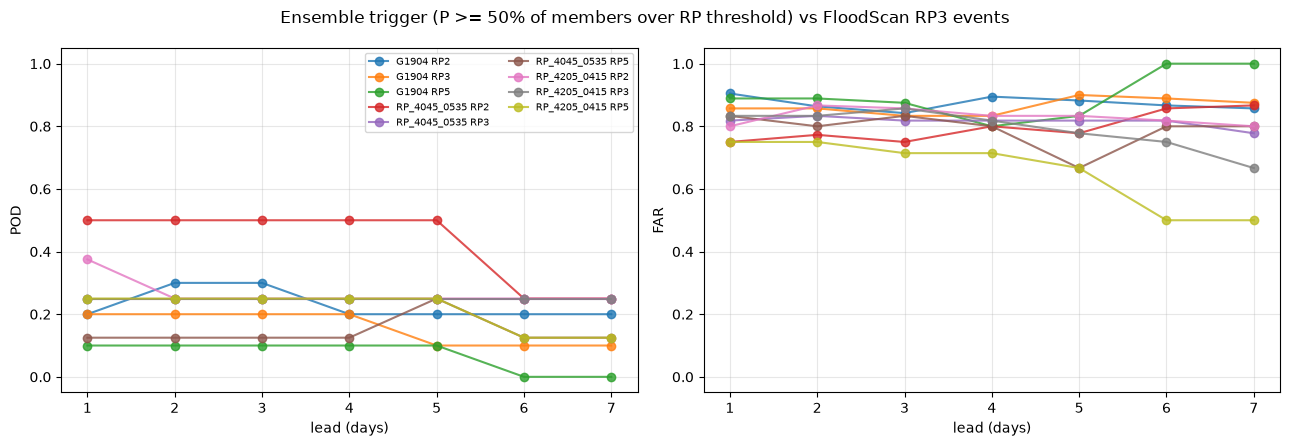

In [5]:
ens = results[results["ensemble"] & (results["prob"] == "0.5") & (results["season"] == "all")]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for ax, metric in zip(axes, ["pod", "far"]):
    for (sid, rp), g in ens.groupby(["station_id", "rp"]):
        ax.plot(g["lead"], g[metric], marker="o", label=f"{sid} RP{rp}", alpha=0.8)
    ax.set_xlabel("lead (days)")
    ax.set_ylabel(metric.upper())
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=7, ncol=2)
plt.suptitle(f"Ensemble trigger (P >= 50% of members over RP threshold) vs FloodScan RP{FS_RP} events")
plt.tight_layout()
plt.show()

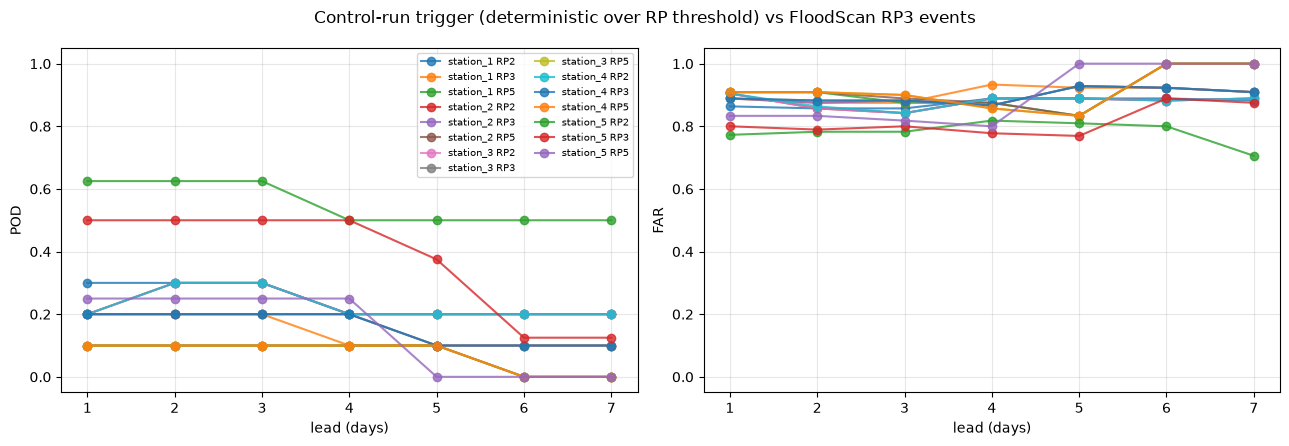

In [6]:
ctl = results[~results["ensemble"] & (results["season"] == "all")]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for ax, metric in zip(axes, ["pod", "far"]):
    for (sid, rp), g in ctl.groupby(["station_id", "rp"]):
        ax.plot(g["lead"], g[metric], marker="o", label=f"{sid} RP{rp}", alpha=0.8)
    ax.set_xlabel("lead (days)")
    ax.set_ylabel(metric.upper())
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=7, ncol=2)
plt.suptitle(f"Control-run trigger (deterministic over RP threshold) vs FloodScan RP{FS_RP} events")
plt.tight_layout()
plt.show()

In [7]:
piv = (
    results[results["prob"].isin(["0.3", "0.5", "0.7"]) & (results["season"] != "all")]
    .pivot_table(index=["station_id", "season", "rp", "prob"], columns="lead", values=["pod", "far"])
    .round(2)
)
piv

far                                       pod  \
lead                            1     2     3     4     5     6     7     1   
station_id   season rp prob                                                   
G1904        deyr   2  0.3   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                       0.5   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                       0.7   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                    3  0.3   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                       0.5   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                       0.7   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                    5  0.3   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                       0.5   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                       0.7   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
             gu     2  0.3   0.80  0.70  0.67  0.78  0.75  0.75  0.75  0.29   
                       0.5   0.80  0.73  0.67  0.78  0.75  0.75  0.75  0.29   
                       0.7   0.80  0.73  0.67  0.75  0.75  0.75  0.75  0.29   
                    3  0.3   0.71  0.71  0.67  0.67  0.83  0.80  0.75  0.29   
                       0.5   0.71  0.71  0.67  0.67  0.80  0.80  0.75  0.29   
                       0.7   0.71  0.71  0.67  0.67  0.80  0.80  0.75  0.29   
                    5  0.3   0.83  0.83  0.80  0.67  0.75  1.00  1.00  0.14   
                       0.5   0.83  0.83  0.80  0.67  0.75  1.00  1.00  0.14   
                       0.7   0.83  0.83  0.80  0.67  0.75  1.00  1.00  0.14   
RP_4045_0535 deyr   2  0.3   0.55  0.62  0.62  0.64  0.69  0.69  0.60  0.67   
                       0.5   0.55  0.62  0.55  0.64  0.56  0.67  0.67  0.67   
                       0.7   0.55  0.58  0.58  0.60  0.57  0.50  0.50  0.67   
                    3  0.3   0.50  0.50  0.60  0.50  0.50  0.50  0.50  0.33   
                       0.5   0.50  0.50  0.50  0.50  0.50  0.50  0.50  0.33   
                       0.7   0.50  0.50  0.50  0.50  0.50  0.50  0.67  0.33   
                    5  0.3   0.50  0.50  0.50  0.50  0.33  0.33  0.50  0.17   
                       0.5   0.50  0.50  0.50  0.50  0.33  0.50  0.50  0.17   
                       0.7   0.50  0.50  0.50  0.50  0.50  0.50  0.50  0.17   
             gu     2  0.3   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                       0.5   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                       0.7   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                    3  0.3   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                       0.5   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                       0.7   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                    5  0.3   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                       0.5   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                       0.7   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
RP_4205_0415 deyr   2  0.3   0.50  0.60  0.60  0.60  0.60  0.50  0.33  0.50   
                       0.5   0.50  0.60  0.60  0.60  0.60  0.33  0.33  0.50   
                       0.7   0.50  0.60  0.60  0.60  0.60  0.33  0.33  0.50   
                    3  0.3   0.60  0.60  0.60  0.33  0.33  0.00  0.00  0.33   
                       0.5   0.60  0.60  0.67  0.33  0.33  0.00  0.00  0.33   
                       0.7   0.60  0.60  0.60  0.33  0.33  0.00  0.00  0.33   
                    5  0.3   0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.33   
                       0.5   0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.33   
                       0.7   0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.33   
             gu     2  0.3   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                       0.5   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
                       0.7   1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.00   
 

## Deyr activation table : proposed trigger legs, year by year

The proposed Deyr legs (see the monitoring dashboard), replayed over the reforecast
archive 2003-2023: a leg fires in a year if, on any issue date with a Deyr-month
valid date, at least 50% of members exceed the leg's Deyr threshold at any lead
(1-7 days). Compared against the FloodScan RP3 Deyr events in the leg's zone.
Gode is included for the record even though v4 is blind there.

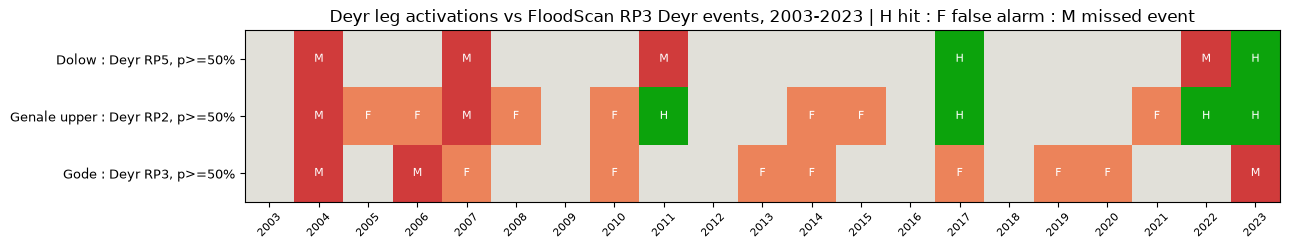

,leg,fires,events,hits,false_alarms,missed,activation_rate,fire_years
0,"Dolow : Deyr RP5, p>=50%",2,6,2,0,4,1 in 10.5 yrs,"2017, 2023"
1,"Genale upper : Deyr RP2, p>=50%",11,6,4,7,2,1 in 1.9 yrs,"2005, 2006, 2008, 2010, 2011, 2014, 2015, 2017..."
2,"Gode : Deyr RP3, p>=50%",7,3,0,7,3,1 in 3.0 yrs,"2007, 2010, 2013, 2014, 2017, 2019, 2020"


In [8]:
LEGS = [
    ("RP_4205_0415", "Dolow : Deyr RP5, p>=50%", 5, 0.5),
    ("RP_4045_0535", "Genale upper : Deyr RP2, p>=50%", 2, 0.5),
    ("G1904", "Gode : Deyr RP3, p>=50%", 3, 0.5),
]
YEARS = list(range(2003, 2024))

leg_fire_years, leg_event_years = {}, {}
for sid, name, rp, gate in LEGS:
    pcode = mapping.loc[sid, "pcode"]
    sub = rf[rf["station_id"] == sid].copy()
    sub = sub[sub["valid_time"].dt.month.isin(SEASON_MONTHS["deyr"])]
    t = thr.loc[(sid, "deyr", rp)]
    prob = (
        sub.assign(over=sub["discharge"] >= t)
        .groupby(["valid_time", "leadtime_days"])["over"].mean()
        .groupby("valid_time").max()
    )
    fired = prob[prob >= gate]
    leg_fire_years[name] = set(fired.index.year)
    ev = fs_events[(fs_events["pcode"] == pcode) & (fs_events["season"] == "deyr")]
    leg_event_years[name] = set(ev["peak_date"].dt.year)

CAT = {"quiet": 0, "hit": 1, "false": 2, "miss": 3}
CAT_COLORS = ["#e1e0d9", "#0ca30c", "#ec835a", "#d03b3b"]
import matplotlib.colors as mcolors
mat = np.zeros((len(LEGS), len(YEARS)))
for i, (_, name, _, _) in enumerate(LEGS):
    for j, y in enumerate(YEARS):
        f, e = y in leg_fire_years[name], y in leg_event_years[name]
        mat[i, j] = CAT["hit"] if f and e else CAT["false"] if f else CAT["miss"] if e else CAT["quiet"]

fig, ax = plt.subplots(figsize=(13, 2.6))
ax.imshow(mat, cmap=mcolors.ListedColormap(CAT_COLORS), vmin=0, vmax=3, aspect="auto")
ax.set_xticks(range(len(YEARS)))
ax.set_xticklabels(YEARS, fontsize=8, rotation=45)
ax.set_yticks(range(len(LEGS)))
ax.set_yticklabels([n for _, n, _, _ in LEGS], fontsize=9)
for i in range(len(LEGS)):
    for j in range(len(YEARS)):
        lbl = {0: "", 1: "H", 2: "F", 3: "M"}[int(mat[i, j])]
        if lbl:
            ax.text(j, i, lbl, ha="center", va="center", fontsize=8,
                    color="white" if mat[i, j] else "black")
ax.set_title("Deyr leg activations vs FloodScan RP3 Deyr events, 2003-2023 | H hit : F false alarm : M missed event")
plt.tight_layout()
plt.show()

summary = pd.DataFrame([
    {
        "leg": name,
        "fires": len(leg_fire_years[name]),
        "events": len(leg_event_years[name]),
        "hits": len(leg_fire_years[name] & leg_event_years[name]),
        "false_alarms": len(leg_fire_years[name] - leg_event_years[name]),
        "missed": len(leg_event_years[name] - leg_fire_years[name]),
        "activation_rate": f"1 in {21 / len(leg_fire_years[name]):.1f} yrs" if leg_fire_years[name] else "never",
        "fire_years": ", ".join(str(y) for y in sorted(leg_fire_years[name])),
    }
    for _, name, _, _ in LEGS
])
summary

## Save outputs

In [9]:
stratus.upload_parquet_to_blob(
    results, f"{PROJECT_PREFIX}/processed/comparison/reforecast_trigger_skill.parquet", stage=STAGE
)
print("saved reforecast trigger skill table")

saved reforecast trigger skill table
